# Autoencoders Recap Notebook: Plain AE, Sparse AE (SAE), VAE, and GAN  
*(Self-contained, runs offline using the scikit-learn digits dataset — 8×8 grayscale images.)*

This notebook gives a **slow, detailed recap** of the ideas we discussed:

- **Plain Autoencoder (AE)**: deterministic compression + reconstruction  
- **Sparse Autoencoder (SAE)**: AE + a sparsity penalty on the latent activations  
- **Variational Autoencoder (VAE)**: probabilistic latent variables + KL regularization  
- **GAN**: generator vs discriminator trained adversarially

We will keep the math explicit and then provide **executable PyTorch code** for each model.

## Dataset (Offline)

We use `sklearn.datasets.load_digits()` (handwritten digits), available offline.

- Images are **8×8** (so input dimension is **64**).
- Pixel values are scaled to **[0, 1]**.


In [1]:
# ---- Setup: imports, reproducibility ----
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits

torch.manual_seed(0)
np.random.seed(0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cpu')

In [2]:
# ---- Load digits dataset (offline) ----
digits = load_digits()
X = digits.data.astype(np.float32)      # shape: (N, 64)
y = digits.target.astype(np.int64)

# scale pixels: original range is 0..16
X = X / 16.0

X_t = torch.tensor(X)
y_t = torch.tensor(y)

dataset = TensorDataset(X_t, y_t)

# Train/val split
N = len(dataset)
n_train = int(0.8 * N)
n_val = N - n_train
train_ds, val_ds = random_split(dataset, [n_train, n_val], generator=torch.Generator().manual_seed(0))

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False)

N, n_train, n_val


(1797, 1437, 360)

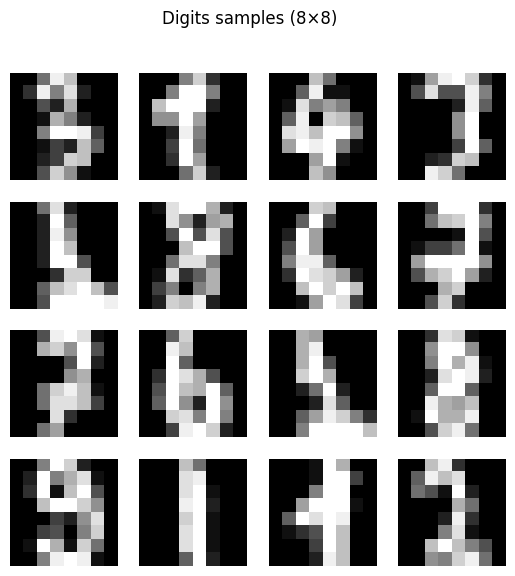

In [3]:
def show_images(flat_batch, title="", n=16):
    """flat_batch: Tensor [B, 64] or numpy array"""
    if isinstance(flat_batch, torch.Tensor):
        imgs = flat_batch.detach().cpu().numpy()
    else:
        imgs = flat_batch
    n = min(n, imgs.shape[0])
    cols = int(math.sqrt(n))
    rows = int(math.ceil(n / cols))
    plt.figure(figsize=(cols*1.6, rows*1.6))
    for i in range(n):
        plt.subplot(rows, cols, i+1)
        plt.imshow(imgs[i].reshape(8, 8), cmap="gray", vmin=0, vmax=1)
        plt.axis("off")
    plt.suptitle(title)
    plt.show()

xb, yb = next(iter(train_loader))
show_images(xb, title="Digits samples (8×8)")


---  

# 1) Plain Autoencoder (AE)

## 1.1 Theory

A deterministic autoencoder is:

- **Encoder**: maps input $x \in \mathbb{R}^d$ to a latent vector $z \in \mathbb{R}^k$

$$
z = f_{\text{enc}}(x)
$$

- **Decoder**: maps latent $z$ back to a reconstruction $\hat{x} \in \mathbb{R}^d$

$$
\hat{x} = f_{\text{dec}}(z)
$$

Training objective:

$$
\mathcal{L}_{\text{AE}} = \lVert x - \hat{x} \rVert_2^2
$$

### Latent vector vs activation

- $z$ is the **latent vector** (encoder output).
- In neural-network language, the output of a layer for a given input is its **activation**.
- Therefore, the entries $z_i$ are also the **activations of the latent-layer neurons**.


In [4]:
# ---- Plain Autoencoder ----
class AE(nn.Module):
    def __init__(self, d_in=64, d_latent=16, d_hidden=128):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(d_in, d_hidden),
            nn.ReLU(),
            nn.Linear(d_hidden, d_latent),
        )
        self.decoder = nn.Sequential(
            nn.Linear(d_latent, d_hidden),
            nn.ReLU(),
            nn.Linear(d_hidden, d_in),
            nn.Sigmoid(),  # outputs in [0, 1]
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat, z

def train_ae(model, train_loader, val_loader, epochs=10, lr=1e-3):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"train": [], "val": []}

    for ep in range(1, epochs+1):
        model.train()
        train_loss, n = 0.0, 0
        for x, _ in train_loader:
            x = x.to(device)
            x_hat, z = model(x)
            loss = F.mse_loss(x_hat, x)
            opt.zero_grad()
            loss.backward()
            opt.step()
            train_loss += loss.item() * x.size(0)
            n += x.size(0)
        train_loss /= n

        model.eval()
        val_loss, n = 0.0, 0
        with torch.no_grad():
            for x, _ in val_loader:
                x = x.to(device)
                x_hat, z = model(x)
                loss = F.mse_loss(x_hat, x)
                val_loss += loss.item() * x.size(0)
                n += x.size(0)
        val_loss /= n

        history["train"].append(train_loss)
        history["val"].append(val_loss)
        if ep == 1 or ep % 2 == 0 or ep == epochs:
            print(f"Epoch {ep:02d} | train MSE={train_loss:.5f} | val MSE={val_loss:.5f}")

    return history

ae = AE(d_in=64, d_latent=16, d_hidden=128)
hist_ae = train_ae(ae, train_loader, val_loader, epochs=10, lr=1e-3)


Epoch 01 | train MSE=0.16390 | val MSE=0.13713
Epoch 02 | train MSE=0.10814 | val MSE=0.08155
Epoch 04 | train MSE=0.07428 | val MSE=0.07338
Epoch 06 | train MSE=0.06918 | val MSE=0.06744
Epoch 08 | train MSE=0.05888 | val MSE=0.05628
Epoch 10 | train MSE=0.04831 | val MSE=0.04622


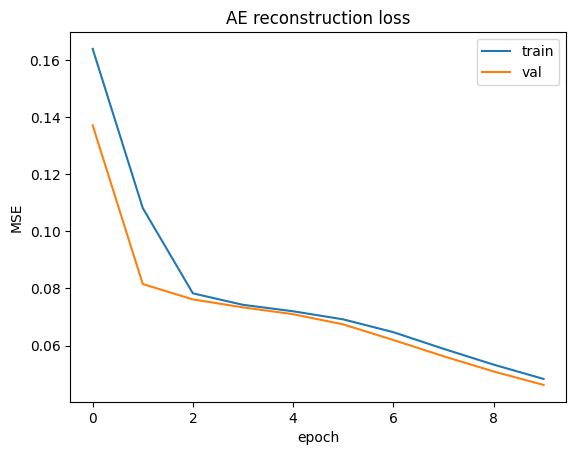

In [5]:
# Plot AE reconstruction loss
plt.figure()
plt.plot(hist_ae["train"], label="train")
plt.plot(hist_ae["val"], label="val")
plt.xlabel("epoch")
plt.ylabel("MSE")
plt.title("AE reconstruction loss")
plt.legend()
plt.show()


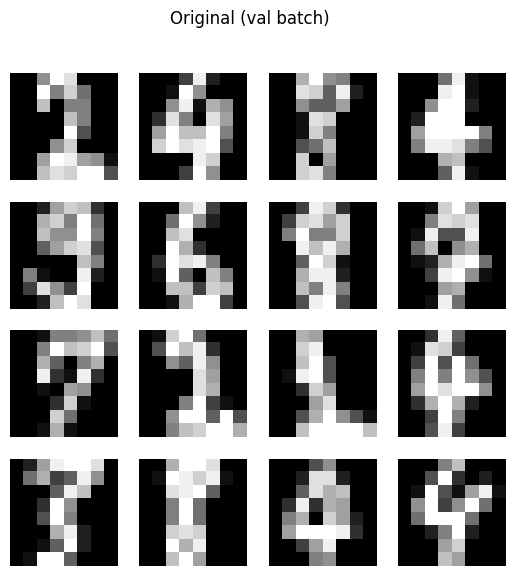

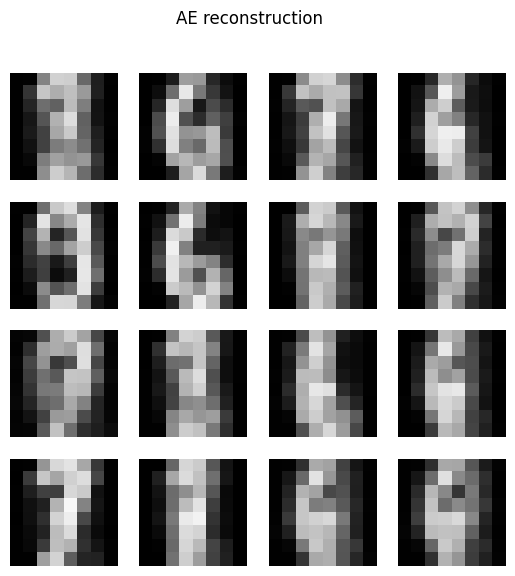

Latent z shape: torch.Size([256, 16])


In [6]:
# Show AE reconstructions
ae.eval()
xb, yb = next(iter(val_loader))
with torch.no_grad():
    x_hat, z = ae(xb.to(device))
show_images(xb, title="Original (val batch)")
show_images(x_hat, title="AE reconstruction")
print("Latent z shape:", z.shape)


---  

# 2) Sparse Autoencoder (SAE)

## 2.1 What changes?

Same encoder/decoder, but we add an L1 penalty on latent activations $z$:

$$
\mathcal{L}_{\text{SAE}} =
\underbrace{\lVert x - \hat{x} \rVert_2^2}_{\text{reconstruction}} +
\lambda \underbrace{\sum_{i=1}^{k} |z_i|}_{\text{sparsity penalty}}
$$

- $|z_i|$ is the absolute value (magnitude) of latent activation $z_i$.
- Penalizing $\sum_i |z_i|$ makes “being active” expensive, so the model uses **few** latent units per input.

### Gradient intuition for L1

For $z_i \neq 0$:

$$
\frac{d}{dz_i}|z_i| = \operatorname{sign}(z_i) =
\begin{cases}
+1 & z_i>0 \\
-1 & z_i<0
\end{cases}
$$

So each nonzero $z_i$ feels a push toward 0.


In [7]:
# ---- Sparse Autoencoder ----
class SAE(nn.Module):
    def __init__(self, d_in=64, d_latent=64, d_hidden=128):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(d_in, d_hidden),
            nn.ReLU(),
            nn.Linear(d_hidden, d_latent),
        )
        self.decoder = nn.Sequential(
            nn.Linear(d_latent, d_hidden),
            nn.ReLU(),
            nn.Linear(d_hidden, d_in),
            nn.Sigmoid(),
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat, z

def train_sae(model, train_loader, val_loader, epochs=10, lr=1e-3, lam=2e-3):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"train": [], "val": [], "train_recon": [], "train_sparse": []}

    for ep in range(1, epochs+1):
        model.train()
        tot, n = 0.0, 0
        recon_tot, sparse_tot = 0.0, 0.0
        for x, _ in train_loader:
            x = x.to(device)
            x_hat, z = model(x)
            recon = F.mse_loss(x_hat, x, reduction="mean")
            sparse = z.abs().mean()  # mean(|z_i|) over batch+features
            loss = recon + lam * sparse

            opt.zero_grad()
            loss.backward()
            opt.step()

            tot += loss.item() * x.size(0)
            recon_tot += recon.item() * x.size(0)
            sparse_tot += sparse.item() * x.size(0)
            n += x.size(0)

        train_loss = tot / n
        train_recon = recon_tot / n
        train_sparse = sparse_tot / n

        model.eval()
        val_loss, n = 0.0, 0
        with torch.no_grad():
            for x, _ in val_loader:
                x = x.to(device)
                x_hat, z = model(x)
                recon = F.mse_loss(x_hat, x, reduction="mean")
                sparse = z.abs().mean()
                loss = recon + lam * sparse
                val_loss += loss.item() * x.size(0)
                n += x.size(0)
        val_loss /= n

        history["train"].append(train_loss)
        history["val"].append(val_loss)
        history["train_recon"].append(train_recon)
        history["train_sparse"].append(train_sparse)

        if ep == 1 or ep % 2 == 0 or ep == epochs:
            print(f"Epoch {ep:02d} | train={train_loss:.5f} (recon={train_recon:.5f}, mean|z|={train_sparse:.5f})"
                  f" | val={val_loss:.5f}")

    return history

sae = SAE(d_in=64, d_latent=64, d_hidden=128)  # overcomplete latent often used in practice
hist_sae = train_sae(sae, train_loader, val_loader, epochs=10, lr=1e-3, lam=2e-3)


Epoch 01 | train=0.16934 (recon=0.16901, mean|z|=0.16698) | val=0.14137
Epoch 02 | train=0.10526 (recon=0.10406, mean|z|=0.60125) | val=0.08208
Epoch 04 | train=0.07497 (recon=0.07296, mean|z|=1.00320) | val=0.07340
Epoch 06 | train=0.06728 (recon=0.06568, mean|z|=0.79978) | val=0.06374
Epoch 08 | train=0.04964 (recon=0.04788, mean|z|=0.88170) | val=0.04558
Epoch 10 | train=0.03920 (recon=0.03729, mean|z|=0.95362) | val=0.03753


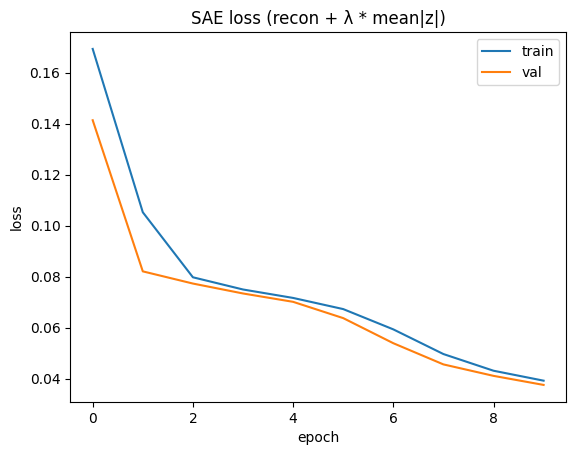

In [8]:
# Plot SAE loss
plt.figure()
plt.plot(hist_sae["train"], label="train")
plt.plot(hist_sae["val"], label="val")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("SAE loss (recon + λ * mean|z|)")
plt.legend()
plt.show()


AE  latent dim: 16 near-zero fraction: 0.0
SAE latent dim: 64 near-zero fraction: 0.00054931640625


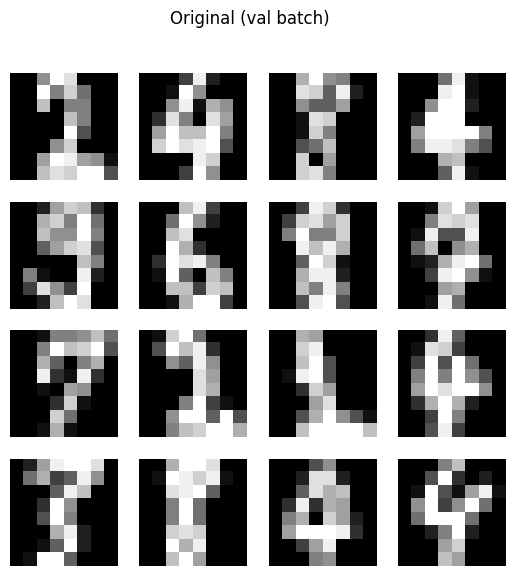

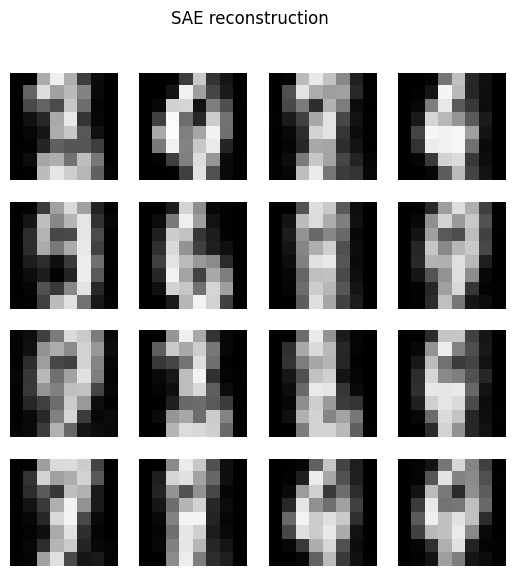

In [9]:
# Compare AE vs SAE latent sparsity on the same validation batch
ae.eval(); sae.eval()
xb, yb = next(iter(val_loader))

with torch.no_grad():
    _, z_ae = ae(xb.to(device))
    _, z_sae = sae(xb.to(device))

def near_zero_fraction(z, eps=1e-3):
    return (z.abs() < eps).float().mean().item()

print("AE  latent dim:", z_ae.shape[1], "near-zero fraction:", near_zero_fraction(z_ae))
print("SAE latent dim:", z_sae.shape[1], "near-zero fraction:", near_zero_fraction(z_sae))

with torch.no_grad():
    xhat_sae, _ = sae(xb.to(device))
show_images(xb, title="Original (val batch)")
show_images(xhat_sae, title="SAE reconstruction")


---  

# 3) Variational Autoencoder (VAE)

## 3.1 Core idea

Instead of a single deterministic $z$, the encoder outputs a **distribution**:

$$
q_{\phi}(z\mid x) = \mathcal{N}\big(\mu_{\phi}(x),\; \mathrm{diag}(\sigma^2_{\phi}(x))\big)
$$

We sample:

$$
z \sim q_{\phi}(z\mid x)
$$

The decoder maps sampled $z$ to $\hat{x}$.

## 3.2 Reparameterization trick

To backprop through sampling:

$$
z = \mu + \sigma \odot \epsilon, \qquad \epsilon \sim \mathcal{N}(0, I)
$$

## 3.3 Loss (ELBO form)

$$
\mathcal{L}_{\text{VAE}} =
\underbrace{\mathbb{E}_{q(z\mid x)}\big[\lVert x-\hat{x} \rVert_2^2\big]}_{\text{reconstruction}} +
\beta \underbrace{D_{\mathrm{KL}}\big(q(z\mid x)\,\|\,p(z)\big)}_{\text{regularization}}
$$

Usually $p(z)=\mathcal{N}(0,I)$ and $\beta=1$.

For diagonal Gaussians:

$$
D_{\mathrm{KL}}\Big(\mathcal{N}(\mu,\sigma^2)\,\|\,\mathcal{N}(0,1)\Big)
= \frac{1}{2}\sum_{j=1}^{k} \left(\mu_j^2 + \sigma_j^2 - \log \sigma_j^2 - 1\right)
$$


In [10]:
# ---- VAE ----
class VAE(nn.Module):
    def __init__(self, d_in=64, d_latent=16, d_hidden=128):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Linear(d_in, d_hidden),
            nn.ReLU(),
        )
        self.mu = nn.Linear(d_hidden, d_latent)
        self.logvar = nn.Linear(d_hidden, d_latent)  # log(sigma^2)

        self.dec = nn.Sequential(
            nn.Linear(d_latent, d_hidden),
            nn.ReLU(),
            nn.Linear(d_hidden, d_in),
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.enc(x)
        return self.mu(h), self.logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + std * eps

    def decode(self, z):
        return self.dec(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_hat = self.decode(z)
        return x_hat, mu, logvar, z

def vae_loss(x, x_hat, mu, logvar, beta=1.0):
    recon = F.mse_loss(x_hat, x, reduction="mean")
    kl = 0.5 * torch.mean(torch.sum(mu**2 + torch.exp(logvar) - logvar - 1.0, dim=1))
    return recon + beta * kl, recon.detach(), kl.detach()

def train_vae(model, train_loader, val_loader, epochs=10, lr=1e-3, beta=1.0):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"train": [], "val": [], "train_recon": [], "train_kl": [], "val_recon": [], "val_kl": []}

    for ep in range(1, epochs+1):
        model.train()
        tot, n = 0.0, 0
        recon_tot, kl_tot = 0.0, 0.0
        for x, _ in train_loader:
            x = x.to(device)
            x_hat, mu, logvar, z = model(x)
            loss, recon, kl = vae_loss(x, x_hat, mu, logvar, beta=beta)
            opt.zero_grad()
            loss.backward()
            opt.step()

            tot += loss.item() * x.size(0)
            recon_tot += recon.item() * x.size(0)
            kl_tot += kl.item() * x.size(0)
            n += x.size(0)

        train_loss = tot / n
        train_recon = recon_tot / n
        train_kl = kl_tot / n

        model.eval()
        tot, n = 0.0, 0
        recon_tot, kl_tot = 0.0, 0.0
        with torch.no_grad():
            for x, _ in val_loader:
                x = x.to(device)
                x_hat, mu, logvar, z = model(x)
                loss, recon, kl = vae_loss(x, x_hat, mu, logvar, beta=beta)
                tot += loss.item() * x.size(0)
                recon_tot += recon.item() * x.size(0)
                kl_tot += kl.item() * x.size(0)
                n += x.size(0)

        val_loss = tot / n
        val_recon = recon_tot / n
        val_kl = kl_tot / n

        history["train"].append(train_loss)
        history["val"].append(val_loss)
        history["train_recon"].append(train_recon)
        history["train_kl"].append(train_kl)
        history["val_recon"].append(val_recon)
        history["val_kl"].append(val_kl)

        if ep == 1 or ep % 2 == 0 or ep == epochs:
            print(f"Epoch {ep:02d} | train={train_loss:.5f} (recon={train_recon:.5f}, kl={train_kl:.5f})"
                  f" | val={val_loss:.5f} (recon={val_recon:.5f}, kl={val_kl:.5f})")
    return history

vae = VAE(d_in=64, d_latent=16, d_hidden=128)
hist_vae = train_vae(vae, train_loader, val_loader, epochs=10, lr=1e-3, beta=1.0)


Epoch 01 | train=0.21743 (recon=0.16150, kl=0.05593) | val=0.16122 (recon=0.13878, kl=0.02244)
Epoch 02 | train=0.14092 (recon=0.12540, kl=0.01552) | val=0.12097 (recon=0.11103, kl=0.00994)
Epoch 04 | train=0.09563 (recon=0.08988, kl=0.00575) | val=0.09056 (recon=0.08550, kl=0.00505)
Epoch 06 | train=0.08356 (recon=0.07989, kl=0.00367) | val=0.08261 (recon=0.07910, kl=0.00350)
Epoch 08 | train=0.07962 (recon=0.07693, kl=0.00269) | val=0.07972 (recon=0.07705, kl=0.00266)
Epoch 10 | train=0.07796 (recon=0.07588, kl=0.00208) | val=0.07861 (recon=0.07650, kl=0.00211)


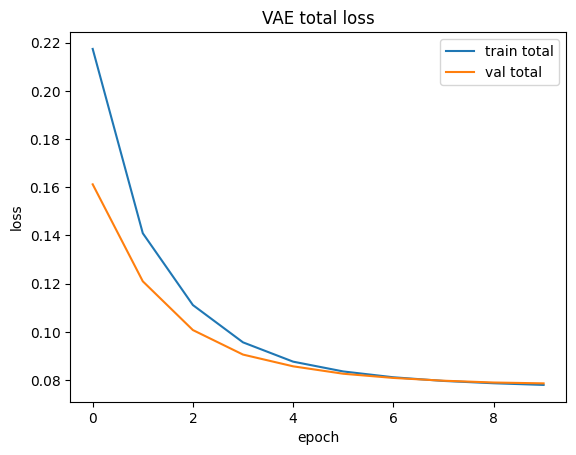

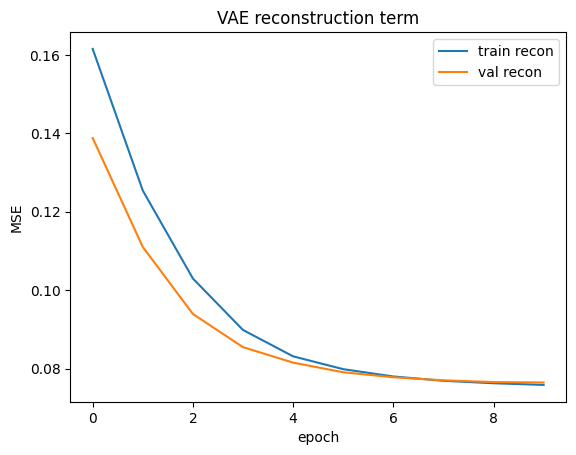

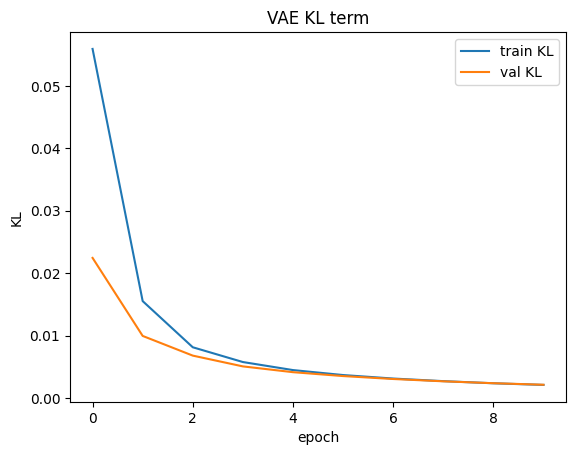

In [11]:
# Plot VAE losses
plt.figure()
plt.plot(hist_vae["train"], label="train total")
plt.plot(hist_vae["val"], label="val total")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("VAE total loss")
plt.legend()
plt.show()

plt.figure()
plt.plot(hist_vae["train_recon"], label="train recon")
plt.plot(hist_vae["val_recon"], label="val recon")
plt.xlabel("epoch")
plt.ylabel("MSE")
plt.title("VAE reconstruction term")
plt.legend()
plt.show()

plt.figure()
plt.plot(hist_vae["train_kl"], label="train KL")
plt.plot(hist_vae["val_kl"], label="val KL")
plt.xlabel("epoch")
plt.ylabel("KL")
plt.title("VAE KL term")
plt.legend()
plt.show()


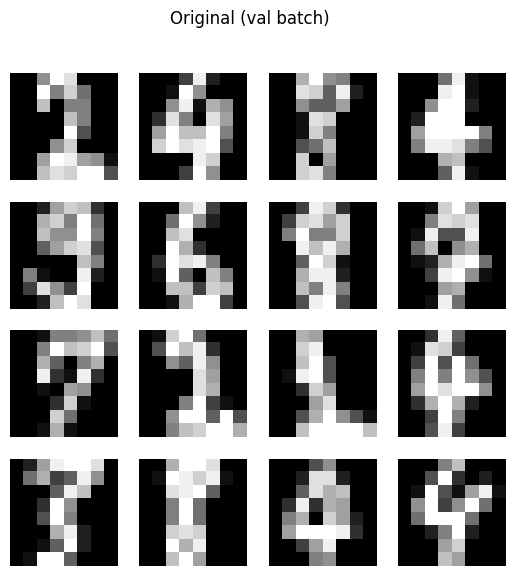

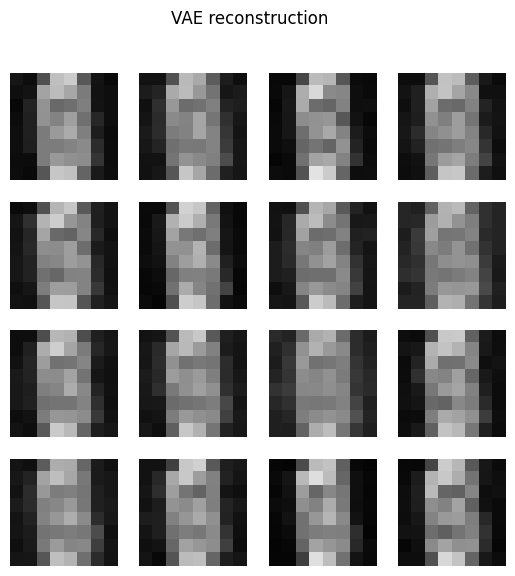

In [12]:
# Show VAE reconstructions
vae.eval()
xb, yb = next(iter(val_loader))
with torch.no_grad():
    x_hat, mu, logvar, z = vae(xb.to(device))
show_images(xb, title="Original (val batch)")
show_images(x_hat, title="VAE reconstruction")


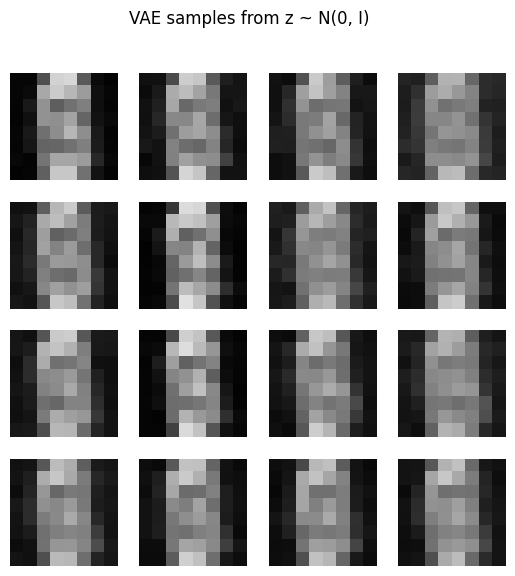

In [13]:
# Generate new samples by sampling z ~ N(0, I)
vae.eval()
with torch.no_grad():
    z = torch.randn(32, 16, device=device)
    samples = vae.decode(z)
show_images(samples, title="VAE samples from z ~ N(0, I)", n=16)


---  

# 4) GAN (Generative Adversarial Network)

## 4.1 Idea

A GAN has two networks:

- **Generator** $G$: noise $u$ → fake sample $\tilde{x}$

$$
\tilde{x} = G(u),\quad u \sim p(u)
$$

- **Discriminator** $D$: predicts real vs fake

$$
D(x) \in (0,1)
$$

Classic minimax objective:

$$
\min_G \max_D \; \mathbb{E}_{x\sim p_{\text{data}}}[\log D(x)] + \mathbb{E}_{u\sim p(u)}[\log(1 - D(G(u)))]
$$

Common practical losses:

$$
\mathcal{L}_D = -\mathbb{E}[\log D(x)] - \mathbb{E}[\log(1 - D(G(u)))]
$$

$$
\mathcal{L}_G = -\mathbb{E}[\log D(G(u))]
$$

GANs have **no reconstruction term**; they learn by adversarial feedback.


In [14]:
# ---- GAN ----
class Generator(nn.Module):
    def __init__(self, z_dim=32, d_out=64, d_hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, d_hidden),
            nn.ReLU(),
            nn.Linear(d_hidden, d_hidden),
            nn.ReLU(),
            nn.Linear(d_hidden, d_out),
            nn.Sigmoid(),
        )
    def forward(self, z):
        return self.net(z)

class Discriminator(nn.Module):
    def __init__(self, d_in=64, d_hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_in, d_hidden),
            nn.LeakyReLU(0.2),
            nn.Linear(d_hidden, d_hidden),
            nn.LeakyReLU(0.2),
            nn.Linear(d_hidden, 1),
            nn.Sigmoid(),
        )
    def forward(self, x):
        return self.net(x)

def train_gan(G, D, train_loader, epochs=25, lr=2e-4, z_dim=32):
    G, D = G.to(device), D.to(device)
    optG = torch.optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
    optD = torch.optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))
    history = {"lossG": [], "lossD": []}

    for ep in range(1, epochs+1):
        G.train(); D.train()
        lossG_ep, lossD_ep, n_batches = 0.0, 0.0, 0

        for x, _ in train_loader:
            x = x.to(device)
            bs = x.size(0)

            real = torch.ones(bs, 1, device=device)
            fake = torch.zeros(bs, 1, device=device)

            # ---- Train Discriminator ----
            out_real = D(x)
            loss_real = F.binary_cross_entropy(out_real, real)

            z = torch.randn(bs, z_dim, device=device)
            x_fake = G(z).detach()
            out_fake = D(x_fake)
            loss_fake = F.binary_cross_entropy(out_fake, fake)

            lossD = loss_real + loss_fake
            optD.zero_grad()
            lossD.backward()
            optD.step()

            # ---- Train Generator ----
            z = torch.randn(bs, z_dim, device=device)
            x_fake = G(z)
            out = D(x_fake)
            lossG = F.binary_cross_entropy(out, real)

            optG.zero_grad()
            lossG.backward()
            optG.step()

            lossG_ep += lossG.item()
            lossD_ep += lossD.item()
            n_batches += 1

        history["lossG"].append(lossG_ep / n_batches)
        history["lossD"].append(lossD_ep / n_batches)

        if ep == 1 or ep % 5 == 0 or ep == epochs:
            print(f"Epoch {ep:02d} | lossD={history['lossD'][-1]:.4f} | lossG={history['lossG'][-1]:.4f}")

    return history

G = Generator(z_dim=32, d_out=64, d_hidden=128)
D = Discriminator(d_in=64, d_hidden=128)
hist_gan = train_gan(G, D, train_loader, epochs=25, lr=2e-4, z_dim=32)


Epoch 01 | lossD=1.2955 | lossG=0.8048
Epoch 05 | lossD=0.9746 | lossG=0.9924
Epoch 10 | lossD=1.1689 | lossG=0.8640
Epoch 15 | lossD=1.1682 | lossG=0.8079
Epoch 20 | lossD=1.1151 | lossG=0.9006
Epoch 25 | lossD=0.9427 | lossG=1.0350


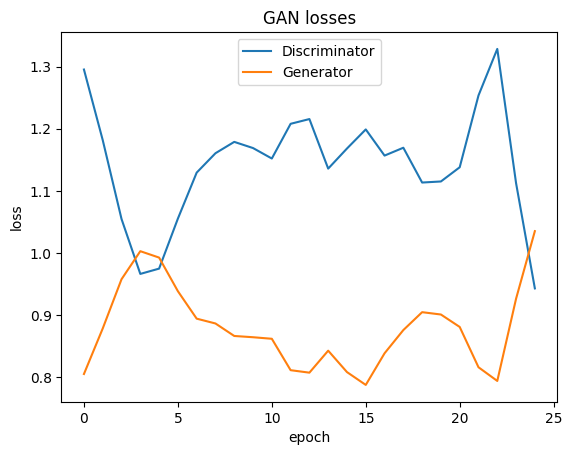

In [15]:
# Plot GAN losses
plt.figure()
plt.plot(hist_gan["lossD"], label="Discriminator")
plt.plot(hist_gan["lossG"], label="Generator")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("GAN losses")
plt.legend()
plt.show()


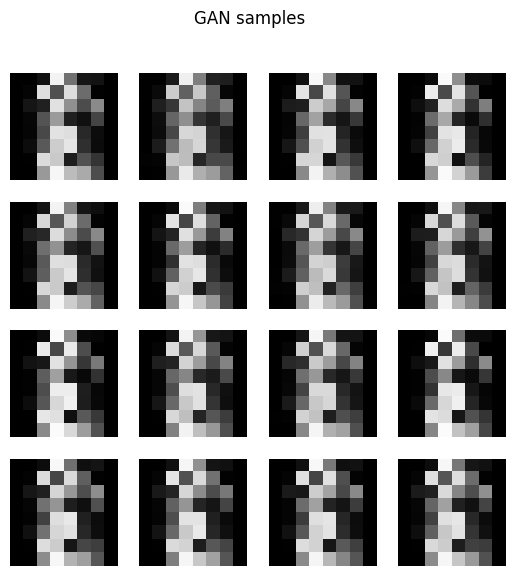

In [16]:
# Generate GAN samples
G.eval()
with torch.no_grad():
    z = torch.randn(32, 32, device=device)
    samples = G(z)
show_images(samples, title="GAN samples", n=16)


---  

# 5) Quick connection back to SAEs in mechanistic interpretability

In transformer interpretability, an SAE often takes as input a **transformer activation vector** $a$ (not pixels).

- Input: $x = a$ (dense activations)
- Encoder outputs: $z$ (sparse feature activations)
- Decoder reconstructs: $\hat{a}$

$$
a \approx W_d z
$$

Sparsity encourages each token’s activation to be explained by a **small set of features**, which are easier to interpret and manipulate.

## Checklist
- **AE**: deterministic reconstructor.
- **SAE**: AE + L1 penalty on latent activations.
- **VAE**: probabilistic latent + KL to a prior.
- **GAN**: adversarial generator/discriminator; no reconstruction term.
